Original Data Shape: (150, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Mean after scaling:
[-0. -0. -0. -0.]

Standard Deviation after scaling:
[1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance Matrix:
[[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Eigenvalues:
[2.938 0.92  0.148 0.021]

Explained Variance Ratio:
[0.73  0.229 0.037 0.005]

Cumulative Variance (First 2 Components):
0.958

Transformed Data Shape (Scratch):
(150, 2)

PCA USING SCIKIT-LEARN

Explained Variance Ratio:
[0.73  0.229]

Cumulative Variance:
0.958

Transformed Data Shape:
(150, 2)


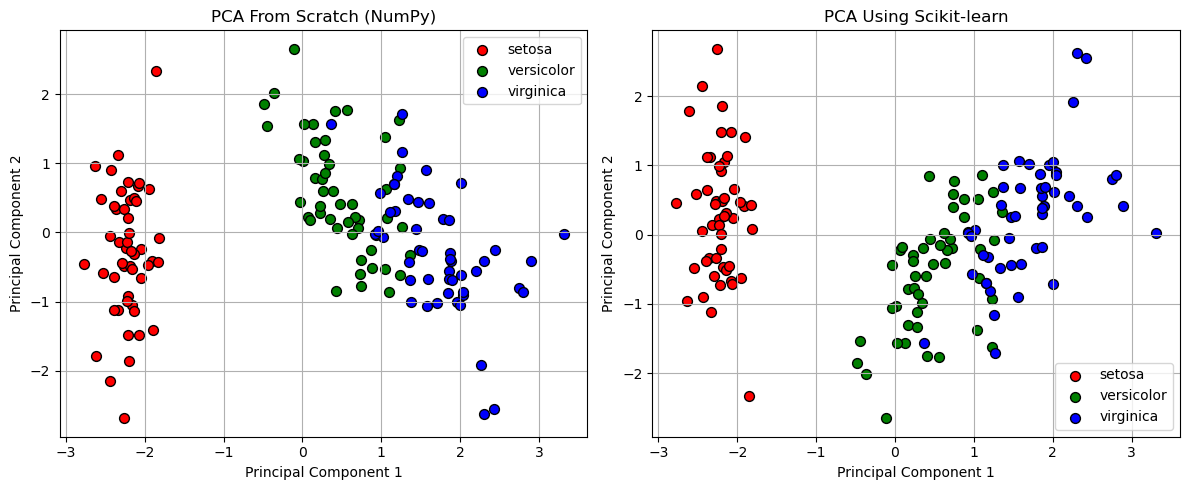


Sanity Check Passed!
Scratch implementation matches Scikit-learn.


In [ ]:
"""
PCA Laboratory Demonstration

This program demonstrates Principal Component Analysis (PCA) in two ways:
1. PCA from scratch using NumPy
2. PCA using scikit-learn

Dataset: Iris Dataset
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------------------------------
# STEP 1: Load the Dataset
# ----------------------------------------------------
iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names

print("Original Data Shape:", X.shape)
print("Feature Names:", feature_names)

# ----------------------------------------------------
# STEP 2: Standardize the Data
# ----------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling:")
print(np.round(X_scaled.mean(axis=0), 3))

print("\nStandard Deviation after scaling:")
print(np.round(X_scaled.std(axis=0), 3))

# ----------------------------------------------------
# STEP 3A: PCA FROM SCRATCH
# ----------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# Covariance Matrix
cov_matrix = np.cov(X_scaled.T)

print("\nCovariance Matrix:")
print(np.round(cov_matrix, 3))

# Eigenvalues and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Sort Eigenvalues in descending order
sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

print("\nEigenvalues:")
print(np.round(eigen_values, 3))

# Explained Variance
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("\nExplained Variance Ratio:")
print(np.round(explained_variance_ratio, 3))

print("\nCumulative Variance (First 2 Components):")
print(np.round(np.sum(explained_variance_ratio[:2]), 3))

# Select Top 2 Components
k = 2
projection_matrix = eigen_vectors[:, :k]

# Transform Data
X_pca_scratch = X_scaled.dot(projection_matrix)

print("\nTransformed Data Shape (Scratch):")
print(X_pca_scratch.shape)

# ----------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN
# ----------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)

X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(np.round(pca.explained_variance_ratio_, 3))

print("\nCumulative Variance:")
print(np.round(np.sum(pca.explained_variance_ratio_), 3))

print("\nTransformed Data Shape:")
print(X_pca_sklearn.shape)

# ----------------------------------------------------
# STEP 4: Visualization
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["red", "green", "blue"]

target_names = iris.target_names

titles = [
    "PCA From Scratch (NumPy)",
    "PCA Using Scikit-learn"
]

datasets = [
    X_pca_scratch,
    X_pca_sklearn
]

for ax, data, title in zip(axes, datasets, titles):

    for i, target in enumerate(target_names):

        ax.scatter(
            data[y == i, 0],
            data[y == i, 1],
            color=colors[i],
            label=target,
            edgecolor="black",
            s=50
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# STEP 5: Compare Scratch vs Scikit-learn
# ----------------------------------------------------
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6
), "Mismatch between implementations!"

print("\nSanity Check Passed!")
print("Scratch implementation matches Scikit-learn.")